<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_TP4/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_4_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TP4 - Aprendizaje no supervisado

#Ejercicio 1 - Triaje oncológico asistido por algoritmos


---
**Datasets:** `datos_pacientes.csv` y `datos_pacientes_diagnosticados.csv`

**Grupo:** Numero 8  
**Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustin  
**Fecha:** x/04/2026

>Un hospital regional de mediana complejidad atiende una cantidad creciente de pacientes derivados con
sospecha de tumor mamario. El cuello de botella no es la tecnología de diagnóstico (el hospital dispone
de equipamiento para biopsia digital) sino la disponibilidad del personal médico especializado: por
restricciones de recursos humanos, el equipo de oncología puede analizar y emitir diagnóstico definitivo
(benigno o maligno) para no más de 2 pacientes por día.
Actualmente hay 560 pacientes con estudios preliminares ya realizados en el sistema, esperando
diagnóstico. A ese ritmo, el último paciente de la lista esperaría 280 días. Para tumores malignos, esa
demora puede ser la diferencia entre un tratamiento efectivo y uno tardío.
El jefe del servicio de oncología propone implementar un sistema de triaje asistido por algoritmos: usar los
valores de los estudios preliminares disponibles para todos los pacientes (datos_pacientes.csv) para
identificar automáticamente cuáles tienen mayor probabilidad de tumor maligno y priorizarlos en la
agenda. Para calibrar y validar el sistema, el servicio dispone de un conjunto reducido de pacientes ya
diagnosticados por el equipo médico (datos_pacientes_diagnosticados.csv), con su resultado confirmado.
El dataset de estudios contiene 30 características computadas a partir de imágenes digitalizadas de
biopsias. El conjunto diagnosticado incluye, además, la columna diagnosis (M = maligno, B = benigno).
El jefe del servicio no rechazará el sistema si tiene un error ocasional. Lo rechazará si no puede entender
qué hace, si produce resultados inconsistentes o si no puede cuantificar el riesgo de que un paciente
maligno quede al final de la lista.





---


## 0. Configuración del entorno

In [2]:
# Dataset desde el repositorio en Drive

!wget -c --no-check-certificate "https://drive.google.com/uc?export=download&id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&confirm=t" -O datos_pacientes.zip

--2026-04-22 17:52:16--  https://drive.google.com/uc?export=download&id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&confirm=t
Resolving drive.google.com (drive.google.com)... 172.217.214.102, 172.217.214.100, 172.217.214.101, ...
Connecting to drive.google.com (drive.google.com)|172.217.214.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&export=download [following]
--2026-04-22 17:52:16--  https://drive.usercontent.google.com/download?id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.194.132, 2607:f8b0:4001:c10::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.194.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50200 (49K) [application/octet-stream]
Saving to: ‘datos_pacientes.zip’

datos_pacientes.zip 100%[===================>]

In [3]:
!unzip datos_pacientes.zip

Archive:  datos_pacientes.zip
  inflating: datos_pacientes_diagnosticados.csv  
  inflating: datos_pacientes.csv     


In [12]:
# @title *Esta celda importa utilidades comunes al colab*
# @title Importaciones
import sys, os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    silhouette_samples
)
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.pipeline import Pipeline

try:
    import umap
except ImportError:
    !pip install umap-learn -q
    import umap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
print("Entorno listo.")


Entorno listo.


### 0.1 EDA

In [14]:
df_pacientes = pd.read_csv('datos_pacientes.csv')
df_pacientes_diagnosticados = pd.read_csv('datos_pacientes_diagnosticados.csv')

Se muestran los primeros 5 pacientes del dataset_pacientes y revisamos el dataset_pacientes_diagnosticados por completo

In [18]:
print("=== dataset_pacientes ===")
print(f"Dimensión: {df_pacientes.shape}  ({df_pacientes.shape[0]} pacientes, {df_pacientes.shape[1]} columnas)")
print(f"Columnas: {list(df_pacientes.columns)}")
df_pacientes.head()

=== dataset_pacientes ===
Dimensión: (560, 31)  (560 pacientes, 31 columnas)
Columnas: ['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,915940,14.580,13.66,94.29,658.8,0.09832,0.08918,0.08222,0.043490,0.1739,...,16.76,17.24,108.50,862.0,0.1223,0.1928,0.24920,0.09186,0.2626,0.07048
1,893988,11.540,10.72,73.73,409.1,0.08597,0.05969,0.01367,0.008907,0.1833,...,12.34,12.87,81.23,467.8,0.1092,0.1626,0.08324,0.04715,0.3390,0.07434
2,8910251,10.600,18.95,69.28,346.4,0.09688,0.11470,0.06387,0.026420,0.1922,...,11.88,22.94,78.28,424.8,0.1213,0.2515,0.19160,0.07926,0.2940,0.07587
3,8510824,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,10.23,15.66,65.13,314.9,0.1324,0.1148,0.08867,0.06227,0.2450,0.07773
4,90944601,13.780,15.79,88.37,585.9,0.08817,0.06718,0.01055,0.009937,0.1405,...,15.27,17.50,97.90,706.6,0.1072,0.1071,0.03517,0.03312,0.1859,0.06810


In [20]:
print("=== dataset_pacientes_diagnosticados ===")
print(f"Dimensión: {df_pacientes_diagnosticados.shape}  ({df_pacientes_diagnosticados.shape[0]} pacientes, {df_pacientes_diagnosticados.shape[1]} columnas)")
print(f"Distribución de diagnóstico:\n{df_pacientes_diagnosticados['diagnosis'].value_counts()}")
df_pacientes_diagnosticados.head()

=== dataset_pacientes_diagnosticados ===
Dimensión: (9, 32)  (9 pacientes, 32 columnas)
Distribución de diagnóstico:
diagnosis
B    6
M    3
Name: count, dtype: int64


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,898677,B,10.26,14.71,66.20,321.6,0.09882,0.09159,0.035810,0.020370,...,10.88,19.48,70.89,357.1,0.1360,0.1636,0.07162,0.04074,0.2434,0.08488
1,913505,M,19.44,18.82,128.10,1167.0,0.10890,0.14480,0.225600,0.119400,...,23.96,30.39,153.90,1740.0,0.1514,0.3725,0.59360,0.20600,0.3266,0.09009
2,912519,B,13.47,14.06,87.32,546.3,0.10710,0.11550,0.057860,0.052660,...,14.83,18.32,94.94,660.2,0.1393,0.2499,0.18480,0.13350,0.3227,0.09326
3,84667401,M,13.73,22.61,93.60,578.3,0.11310,0.22930,0.212800,0.080250,...,15.03,32.01,108.80,697.7,0.1651,0.7725,0.69430,0.22080,0.3596,0.14310
4,874158,B,10.08,15.11,63.76,317.5,0.09267,0.04695,0.001597,0.002404,...,11.87,21.18,75.39,437.0,0.1521,0.1019,0.00692,0.01042,0.2933,0.07697


Vamos a revisar si hay valores nulos en ambas datasets

In [21]:
# Verificación de nulos
print("Nulos en datos_pacientes:")
print(df_pacientes.isnull().sum().sum(), "valores nulos totales")
print("\nNulos en datos_pacientes_diagnosticados:")
print(df_pacientes_diagnosticados.isnull().sum().sum(), "valores nulos totales")

Nulos en datos_pacientes:
0 valores nulos totales

Nulos en datos_pacientes_diagnosticados:
0 valores nulos totales


In [25]:
# Estadísticas descriptivas de los 560 pacientes
df_pacientes.describe().T.style.background_gradient(cmap="Blues", subset=["mean", "std", "min", "max"])

,count,mean,std,min,25%,50%,75%,max
id,560.000000,30536072.607143,125933045.657819,8670.000000,869222.500000,906157.000000,8825022.250000,911320502.000000
radius_mean,560.000000,14.139805,3.524507,6.981000,11.707500,13.355000,15.797500,28.110000
texture_mean,560.000000,19.343804,4.288002,9.710000,16.292500,18.890000,21.812500,39.280000
perimeter_mean,560.000000,92.048107,24.307755,43.790000,75.200000,86.210000,104.150000,188.500000
area_mean,560.000000,656.062500,352.594258,143.500000,420.300000,551.400000,784.150000,2501.000000
smoothness_mean,560.000000,0.096239,0.014122,0.052630,0.085992,0.095720,0.105150,0.163400
compactness_mean,560.000000,0.104211,0.052825,0.019380,0.064815,0.092525,0.130425,0.345400
concavity_mean,560.000000,0.088747,0.079782,0.000000,0.029540,0.061400,0.131000,0.426800
concave points_mean,560.000000,0.048890,0.038822,0.000000,0.020310,0.033455,0.073730,0.201200
symmetry_mean,560.000000,0.181178,0.027575,0.106000,0.161875,0.179250,0.195700,0.304000


### 0.2 Distribución de las features

Visualizamos la distribución de las 30 features para detectar asimetrías, outliers y ver las escalas.

Total de features: 30


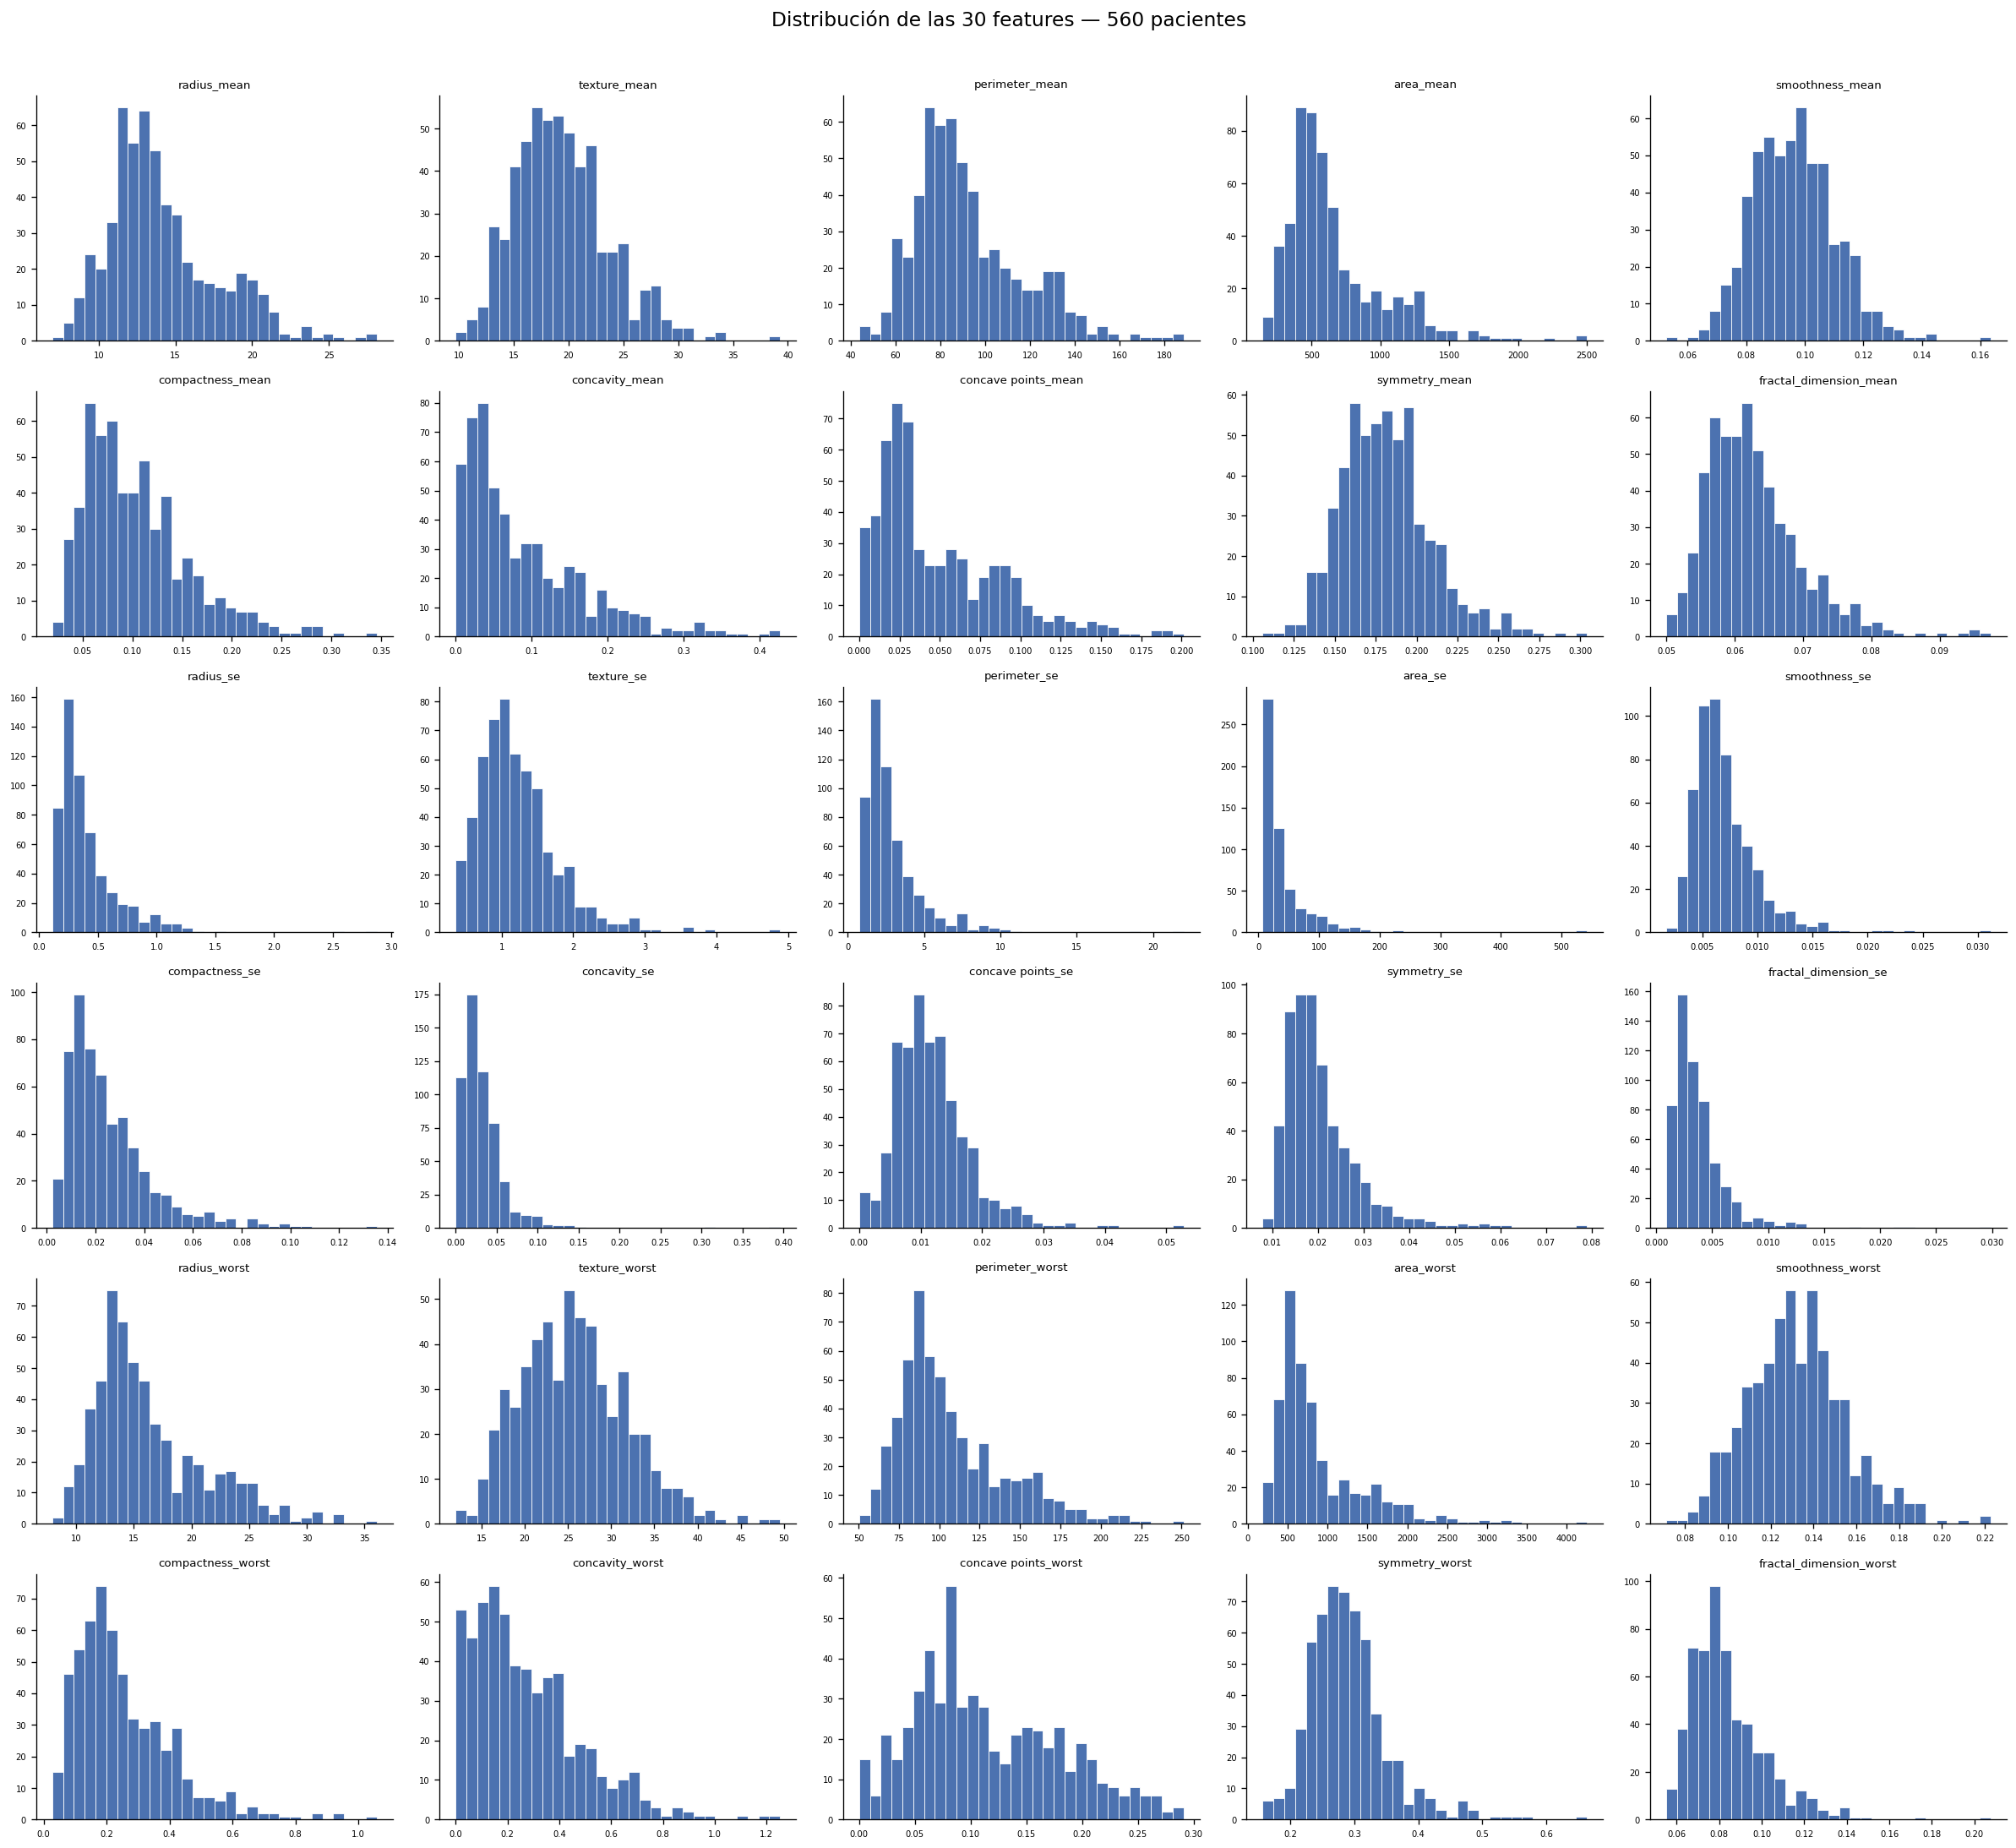

In [26]:
# Identificar columnas de features (excluir id)
feature_cols = [c for c in df_pacientes.columns if c != "id"]
print(f"Total de features: {len(feature_cols)}")

fig, axes = plt.subplots(6, 5, figsize=(20, 18))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(df_pacientes[col], bins=30, color="#4C72B0", edgecolor="white", linewidth=0.5)
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=6)
plt.suptitle("Distribución de las 30 features — 560 pacientes", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Se aprecian que las features tienen distintas escalas (justificación para aplicar `StandardScaler`).

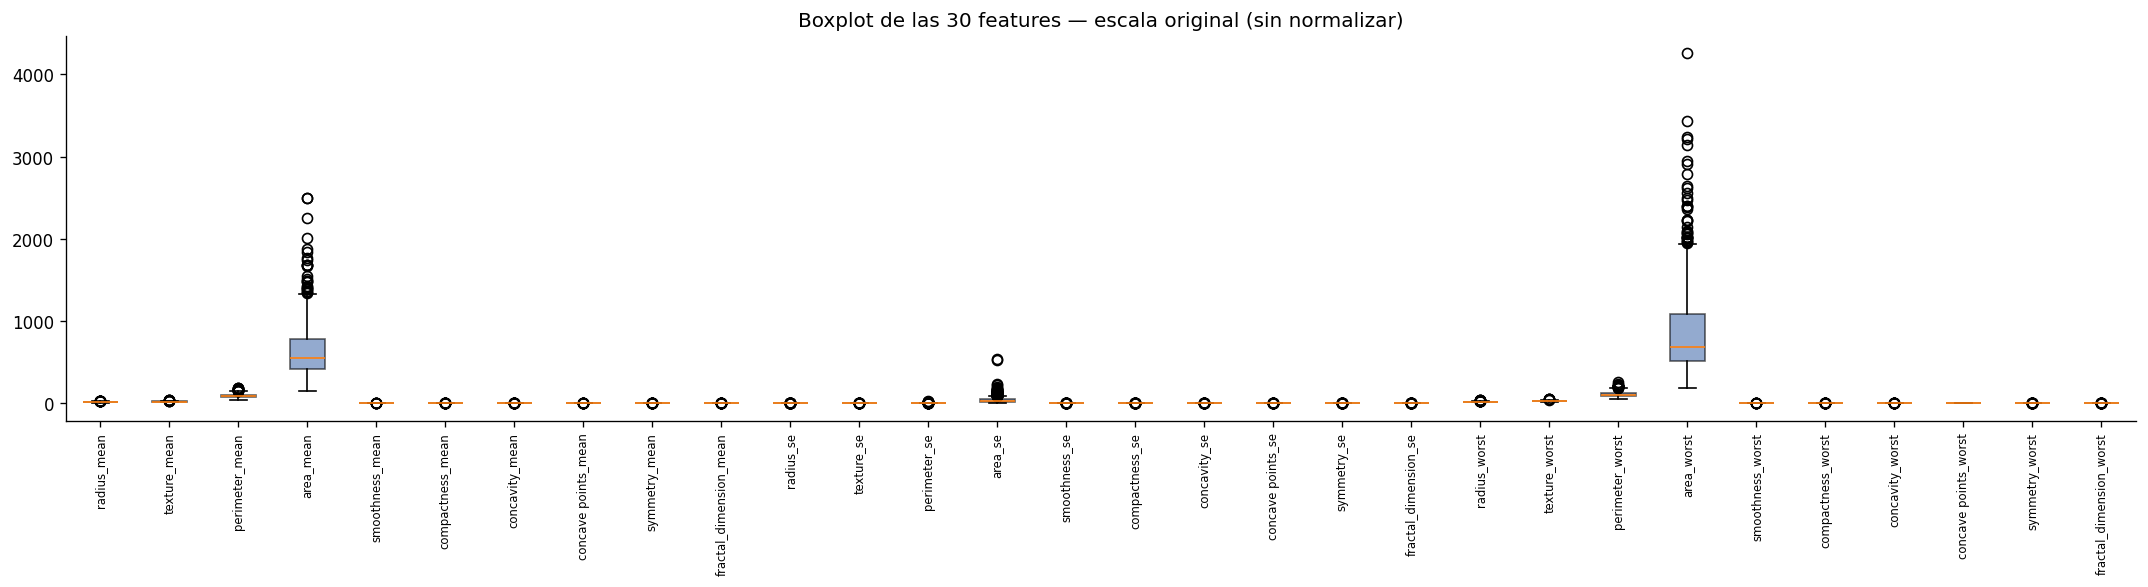

In [28]:
# Boxplot para visualizar rango y outliers por feature
X_raw = df_pacientes[feature_cols].values
fig, ax = plt.subplots(figsize=(18, 5))
ax.boxplot(X_raw, labels=feature_cols, vert=True, patch_artist=True,
           boxprops=dict(facecolor="#4C72B0", alpha=0.6))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=7)
ax.set_title("Boxplot de las 30 features — escala original (sin normalizar)")
plt.tight_layout()
plt.show()

Observación: features como area_mean tienen rango de ~1000 mientras que smoothness_mean tiene rango ~0.1. Sin escalar, K-Means basado en distancias euclidianas estaría dominado por las features de mayor magnitud.

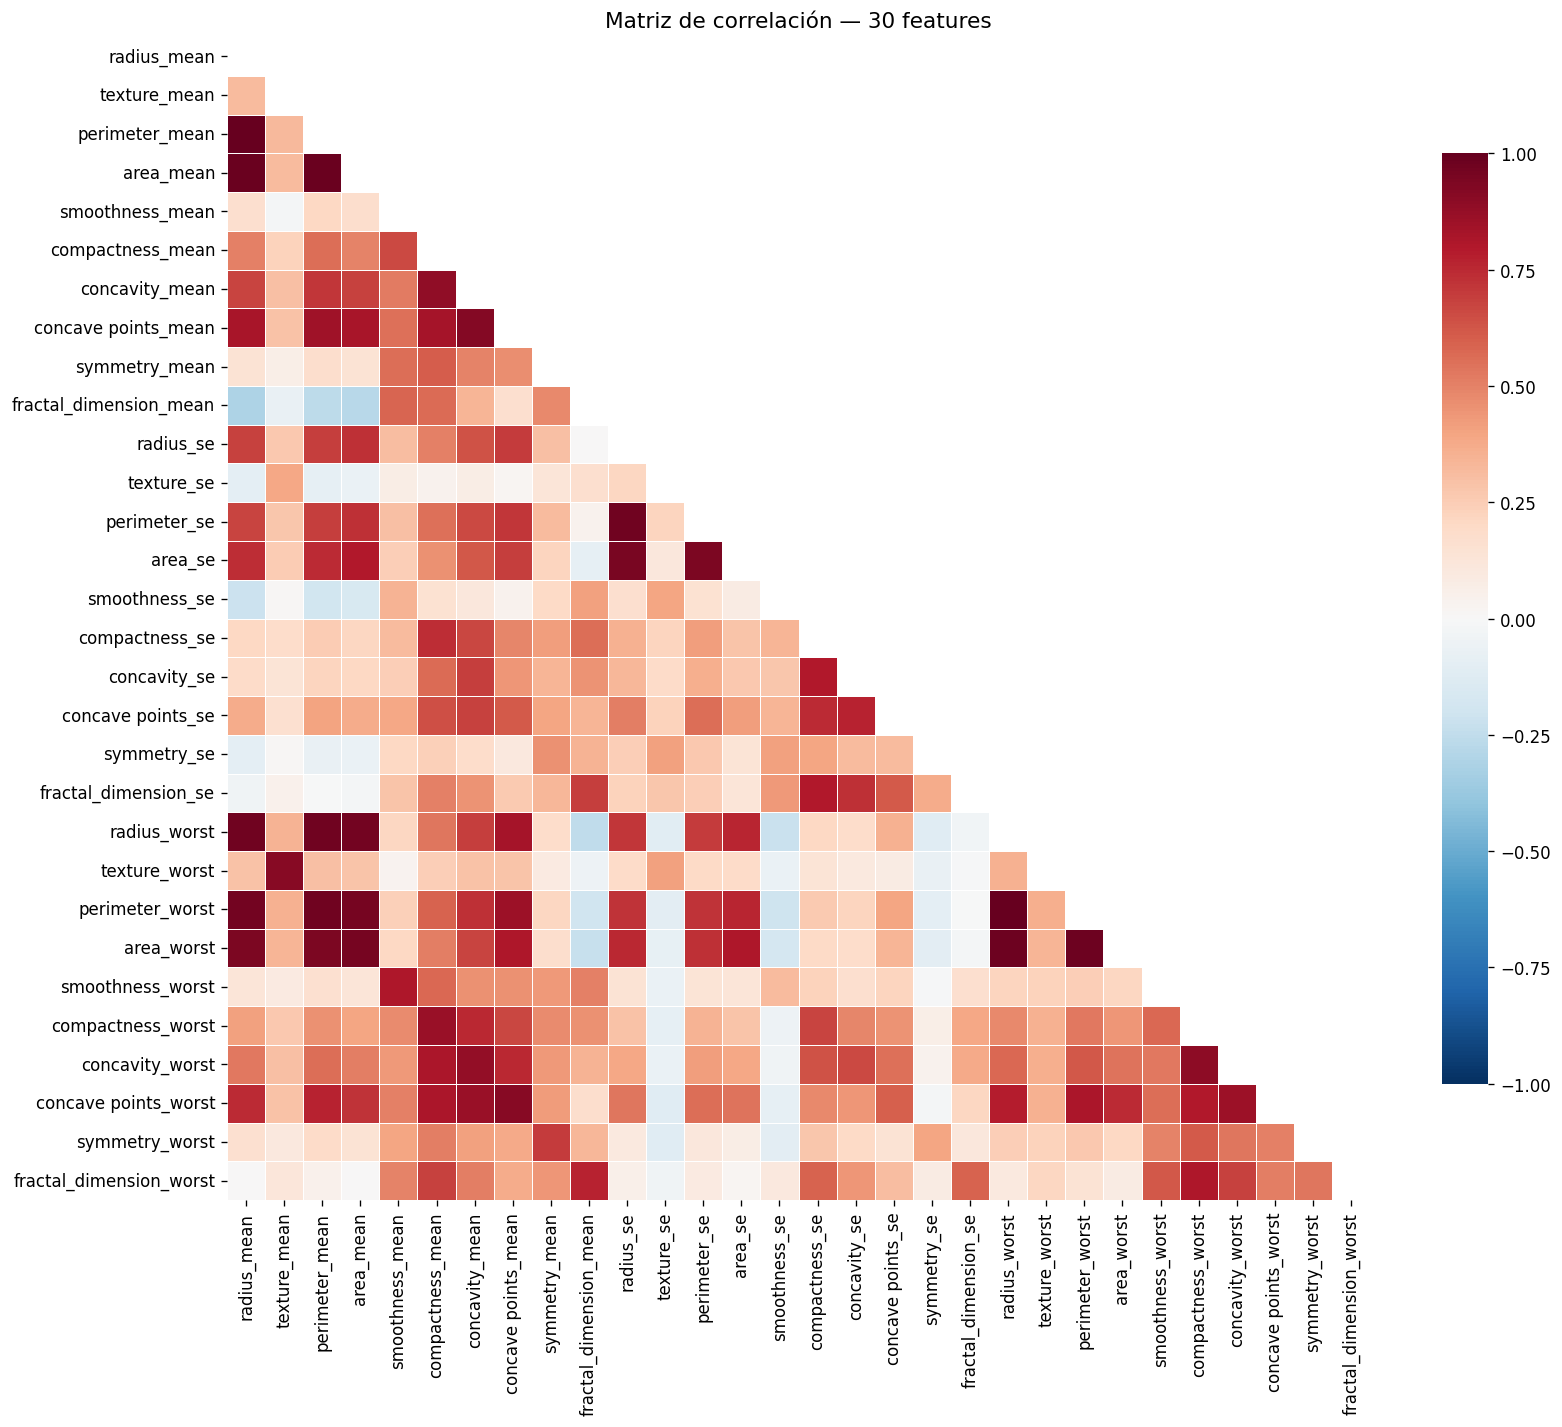

In [30]:
# Mapa de correlación — permite ver si hay redundancia entre features
corr = df_pacientes[feature_cols].corr()
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Matriz de correlación — 30 features", fontsize=13)
plt.tight_layout()
plt.show()

Observación: alta correlación entre features de la misma familia (ej: radius_mean, area_mean, perimeter_mean). Esto sugiere que PCA podrá capturar gran parte de la varianza en pocos componentes.



---


##1. Construcción del Pipeline de Preprocesamiento

El único paso de preprocesamiento necesario es **estandarización** con `StandardScaler`:

- Lleva todas las features a media 0 y desviación estándar 1
- Fundamental para K-Means, que usa distancias euclidianas
- Sin escalar, `area_mean` (1000) dominaría completamente sobre `smoothness_mean` (~0.1)
- La columna `id` se descarta para el modelado (se preserva para identificación final)

In [31]:
# Separar IDs y features
ids_pac = df_pacientes["id"].values
X_raw = df_pacientes[feature_cols].values

# Pipeline de preprocesamiento
preprocesador = Pipeline([
    ("scaler", StandardScaler())
])

X_scaled = preprocesador.fit_transform(X_raw)

print(f"Shape antes de escalar: {X_raw.shape}")
print(f"Shape después de escalar: {X_scaled.shape}")
print(f"\nMedia post-scaling (debe ser ~0): {X_scaled.mean(axis=0).mean():.6f}")
print(f"Std post-scaling (debe ser ~1): {X_scaled.std(axis=0).mean():.6f}")

# También preparar el dataset diagnosticado
X_diag_raw = df_pacientes_diagnosticados[feature_cols].values
X_diag_scaled = preprocesador.transform(X_diag_raw)  # transform, NO fit_transform
y_diag = df_pacientes_diagnosticados["diagnosis"].values  # M / B
print(f"\nDataset diagnosticado escalado: {X_diag_scaled.shape}")
print(f"Diagnósticos: {pd.Series(y_diag).value_counts().to_dict()}")

Shape antes de escalar: (560, 30)
Shape después de escalar: (560, 30)

Media post-scaling (debe ser ~0): -0.000000
Std post-scaling (debe ser ~1): 1.000000

Dataset diagnosticado escalado: (9, 30)
Diagnósticos: {'B': 6, 'M': 3}


## 2. Reduccion de Dimensionalidad y Visualización

Las 30 features haran que sea dificil visualizar los datos, entonces se pueden optar por el uso de tecnicas para reducir la dimensionalidad, algunas tecnicas son:

*   PCA
*   t-SNE
*   UMAP

Los pacientes diagnosticados como M se pintarán de rojo y los diagnosticados como B de verde.



---


##2. Reducción de Dimensionalidad y Visualización

### 2.1 PCA — Principal Component Analysis

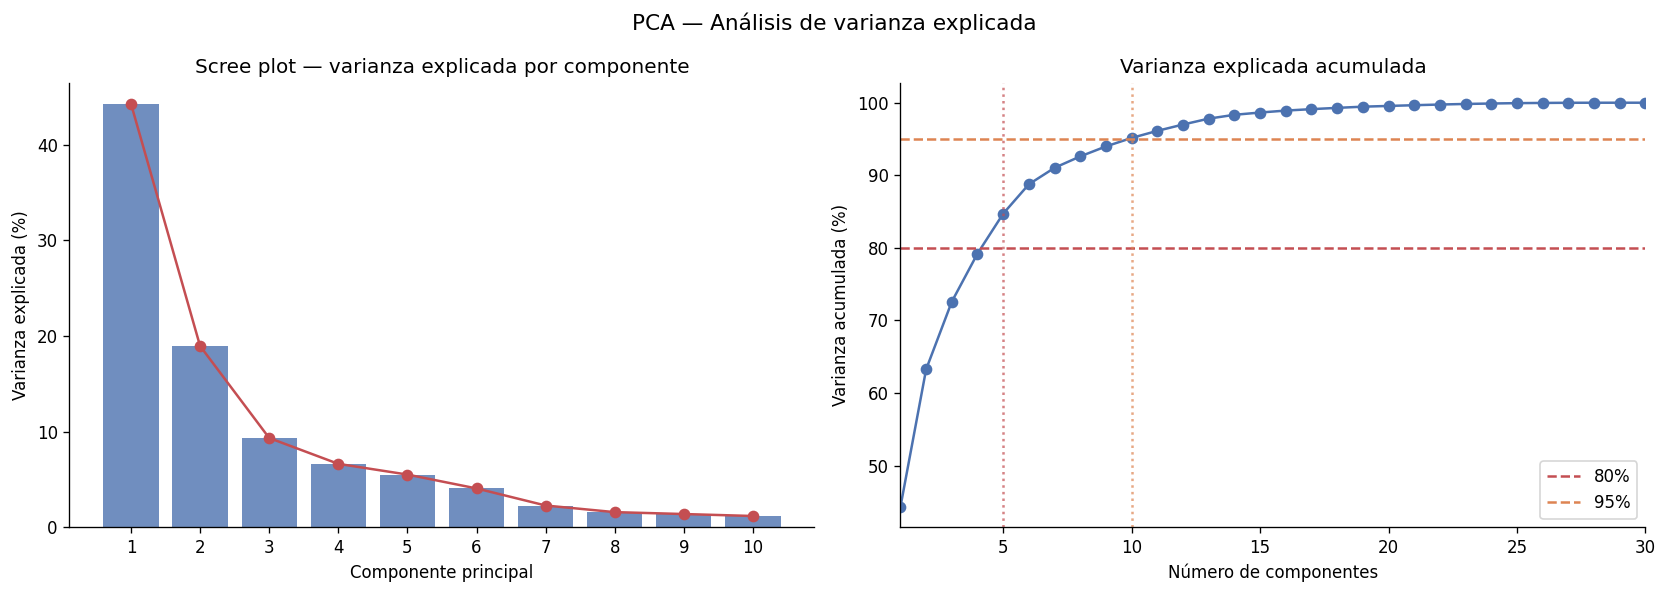

PC1: 44.3% de varianza
PC2: 19.0% de varianza
PC1+PC2 combinados: 63.3% de varianza

Componentes necesarios para explicar el 80% de la varianza: 5
Componentes necesarios para explicar el 95% de la varianza: 10

Interpretación: al proyectar a 2D con PCA perdemos ~36.7% de la información.
Sin embargo, si la estructura de separación está principalmente en los primeros PC,
la visualización 2D puede ser muy representativa.


In [32]:
# PCA completo para ver varianza explicada
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax1.bar(range(1, 11), pca_full.explained_variance_ratio_[:10] * 100, color="#4C72B0", alpha=0.8)
ax1.plot(range(1, 11), pca_full.explained_variance_ratio_[:10] * 100, "o-", color="#C44E52")
ax1.set_xlabel("Componente principal")
ax1.set_ylabel("Varianza explicada (%)")
ax1.set_title("Scree plot — varianza explicada por componente")
ax1.set_xticks(range(1, 11))

# Varianza acumulada
ax2.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada * 100, "o-", color="#4C72B0")
ax2.axhline(80, ls="--", color="#C44E52", label="80%")
ax2.axhline(95, ls="--", color="#DD8452", label="95%")
n_80 = np.argmax(varianza_acumulada >= 0.80) + 1
n_95 = np.argmax(varianza_acumulada >= 0.95) + 1
ax2.axvline(n_80, ls=":", color="#C44E52", alpha=0.7)
ax2.axvline(n_95, ls=":", color="#DD8452", alpha=0.7)
ax2.set_xlabel("Número de componentes")
ax2.set_ylabel("Varianza acumulada (%)")
ax2.set_title("Varianza explicada acumulada")
ax2.legend()
ax2.set_xlim(1, 30)

plt.suptitle("PCA — Análisis de varianza explicada", fontsize=13)
plt.tight_layout()
plt.show()

pc1_var = pca_full.explained_variance_ratio_[0] * 100
pc2_var = pca_full.explained_variance_ratio_[1] * 100
print(f"PC1: {pc1_var:.1f}% de varianza")
print(f"PC2: {pc2_var:.1f}% de varianza")
print(f"PC1+PC2 combinados: {pc1_var + pc2_var:.1f}% de varianza")
print(f"\nComponentes necesarios para explicar el 80% de la varianza: {n_80}")
print(f"Componentes necesarios para explicar el 95% de la varianza: {n_95}")
print(f"\nInterpretación: al proyectar a 2D con PCA perdemos ~{100-(pc1_var+pc2_var):.1f}% de la información.")
print("Sin embargo, si la estructura de separación está principalmente en los primeros PC,")
print("la visualización 2D puede ser muy representativa.")

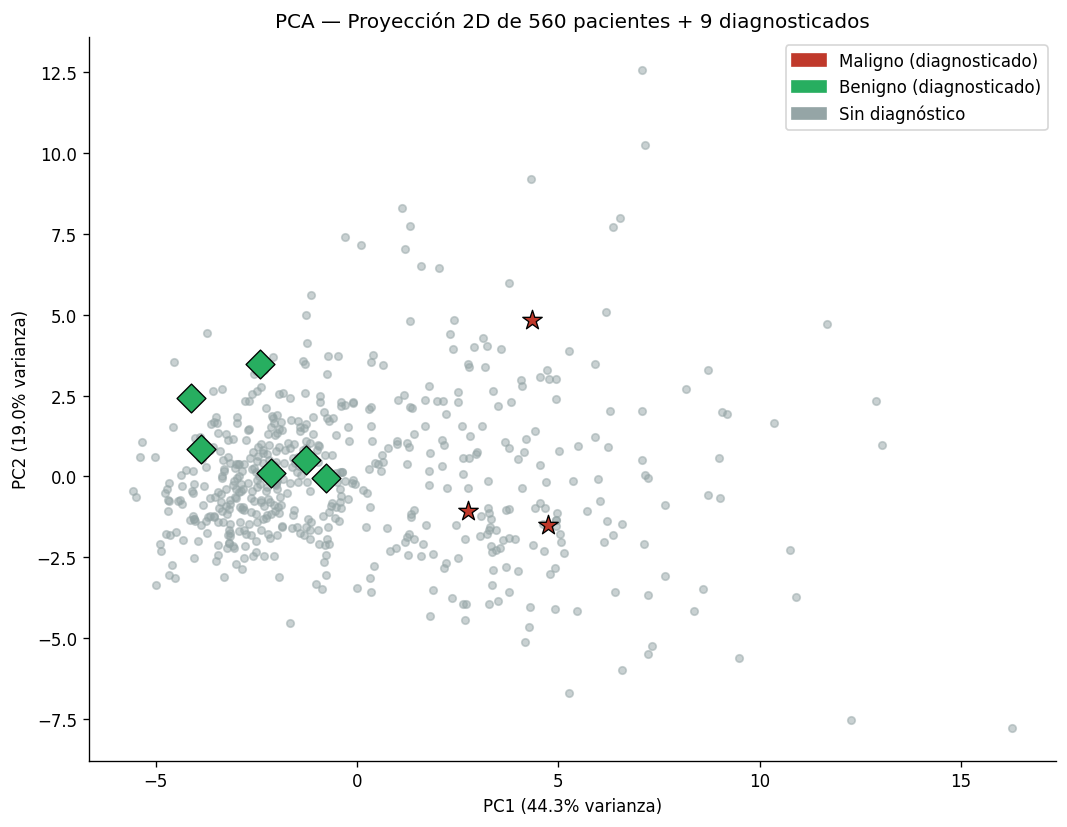

In [34]:
# Proyección 2D con PCA
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X_scaled)
X_diag_pca = pca_2d.transform(X_diag_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_pca[:, 0], X_pca[:, 1], c="#95A5A6", s=20, alpha=0.5, label="Sin diagnóstico (560)")

# Superponer diagnosticados
colores_diag = ["#C0392B" if d == "M" else "#27AE60" for d in y_diag]
for i, (x, y_) in enumerate(X_diag_pca):
    ax.scatter(x, y_, c=colores_diag[i], s=150, zorder=5,
               marker="*" if y_diag[i] == "M" else "D",
               edgecolors="black", linewidths=0.8)

patch_m = mpatches.Patch(color="#C0392B", label="Maligno (diagnosticado)")
patch_b = mpatches.Patch(color="#27AE60", label="Benigno (diagnosticado)")
patch_u = mpatches.Patch(color="#95A5A6", label="Sin diagnóstico")
ax.legend(handles=[patch_m, patch_b, patch_u], loc="best")
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)")
ax.set_title("PCA — Proyección 2D de 560 pacientes + 9 diagnosticados")
plt.tight_layout()
plt.show()

Observación: si se ven dos nubes separadas, la estructura es lineal y fuerte.

### 2.2 t-SNE — t-Distributed Stochastic Neighbor Embedding

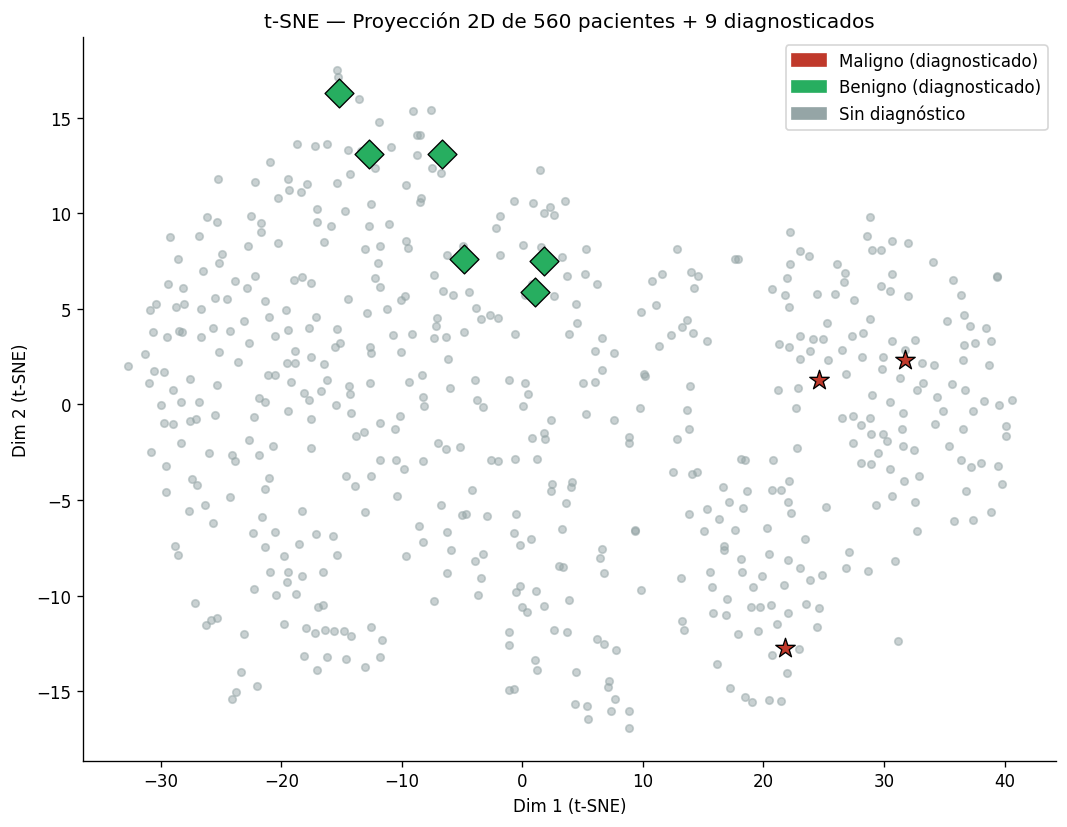

In [35]:
# t-SNE — combinar los 560 + 9 para proyectarlos juntos
X_combined = np.vstack([X_scaled, X_diag_scaled])
labels_combined = ["sin_dx"] * len(X_scaled) + list(y_diag)

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000,
            random_state=RANDOM_STATE, learning_rate="auto", init="pca")
X_tsne_all = tsne.fit_transform(X_combined)

X_tsne = X_tsne_all[:len(X_scaled)]
X_diag_tsne = X_tsne_all[len(X_scaled):]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c="#95A5A6", s=20, alpha=0.5, label="Sin diagnóstico (560)")
colores_diag = ["#C0392B" if d == "M" else "#27AE60" for d in y_diag]
for i, (x, y_) in enumerate(X_diag_tsne):
    ax.scatter(x, y_, c=colores_diag[i], s=150, zorder=5,
               marker="*" if y_diag[i] == "M" else "D",
               edgecolors="black", linewidths=0.8)
patch_m = mpatches.Patch(color="#C0392B", label="Maligno (diagnosticado)")
patch_b = mpatches.Patch(color="#27AE60", label="Benigno (diagnosticado)")
patch_u = mpatches.Patch(color="#95A5A6", label="Sin diagnóstico")
ax.legend(handles=[patch_m, patch_b, patch_u], loc="best")
ax.set_title("t-SNE — Proyección 2D de 560 pacientes + 9 diagnosticados")
ax.set_xlabel("Dim 1 (t-SNE)")
ax.set_ylabel("Dim 2 (t-SNE)")
plt.tight_layout()
plt.show()

### 2.3 UMAP — Uniform Manifold Approximation and Projection

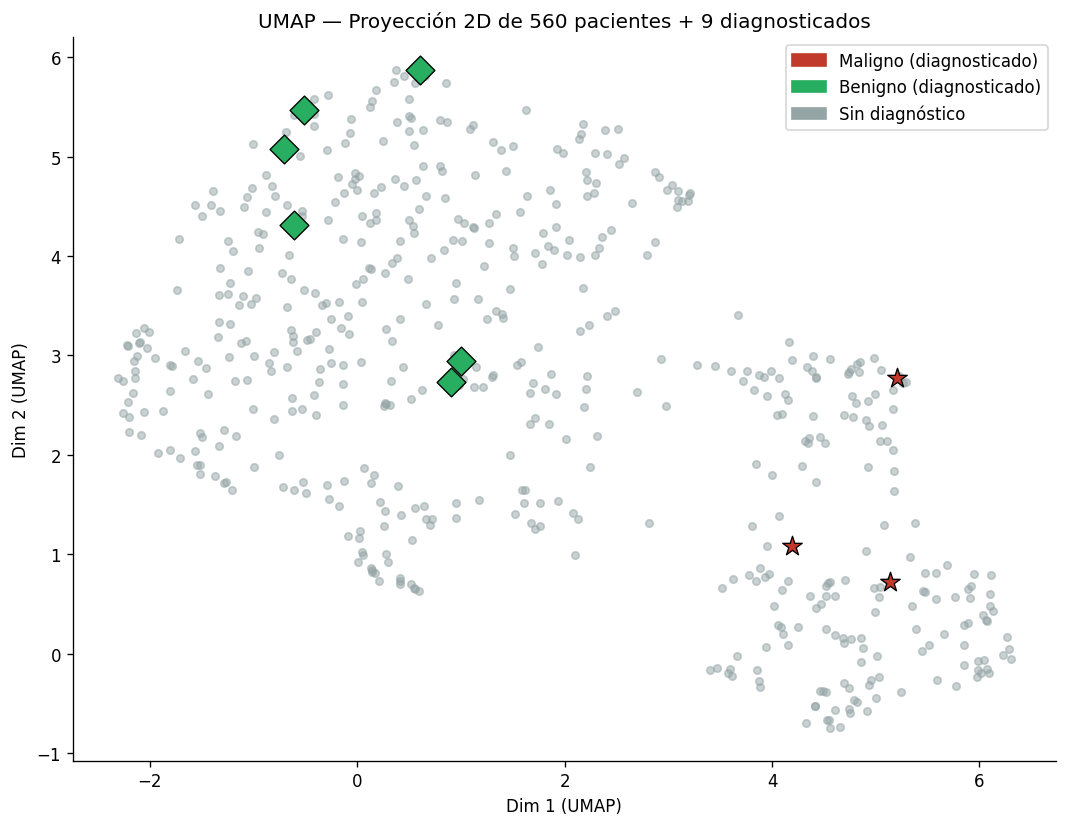

In [36]:
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
X_umap_all = reducer.fit_transform(X_combined)

X_umap = X_umap_all[:len(X_scaled)]
X_diag_umap = X_umap_all[len(X_scaled):]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_umap[:, 0], X_umap[:, 1], c="#95A5A6", s=20, alpha=0.5, label="Sin diagnóstico (560)")
colores_diag = ["#C0392B" if d == "M" else "#27AE60" for d in y_diag]
for i, (x, y_) in enumerate(X_diag_umap):
    ax.scatter(x, y_, c=colores_diag[i], s=150, zorder=5,
               marker="*" if y_diag[i] == "M" else "D",
               edgecolors="black", linewidths=0.8)
patch_m = mpatches.Patch(color="#C0392B", label="Maligno (diagnosticado)")
patch_b = mpatches.Patch(color="#27AE60", label="Benigno (diagnosticado)")
patch_u = mpatches.Patch(color="#95A5A6", label="Sin diagnóstico")
ax.legend(handles=[patch_m, patch_b, patch_u], loc="best")
ax.set_title("UMAP — Proyección 2D de 560 pacientes + 9 diagnosticados")
ax.set_xlabel("Dim 1 (UMAP)")
ax.set_ylabel("Dim 2 (UMAP)")
plt.tight_layout()
plt.show()

### 2.4 Comparación y elección de método

| Método | ¿Qué preserva? | ¿Qué pierde? | Apropiado para este problema |
|--------|---------------|--------------|------------------------------|
| **PCA** | Varianza global / distancias lineales | Estructura no lineal | ✅ Para diagnóstico rápido y varianza explicada |
| **t-SNE** | Vecindarios locales (puntos similares quedan juntos) | Distancias globales (clusters lejanos pueden parecer cerca o lejos sin significado real) | ✅ Para explorar subestructura interna |
| **UMAP** | Estructura local Y global simultáneamente; más rápido que t-SNE | Algo de precisión local vs t-SNE | ✅ **El más apropiado** para este problema: preserva separación entre grupos y estructura interna |

**Conclusión:** UMAP es el método más informativo para este caso. PCA es el más interpretable (varianza explicada cuantificable). t-SNE es útil para exploración visual pero sus distancias inter-cluster no tienen interpretación directa.



---


## 3. Clustering con K-Means

### 3.1 Selección del número óptimo de clusters (K)



Sabemos que tenemos 2 clusters debido al contexto del problema, el cluster B y el cluster M, o eso podria parecer, vamos a verificar si eso ocurre realmente.

In [37]:
# Evaluación para K = 2 a 8
k_range = range(2, 9)
inercias = []
silhouettes = []
davies_bouldins = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    davies_bouldins.append(davies_bouldin_score(X_scaled, labels))
    print(f"K={k}: Inercia={km.inertia_:.1f}, Silhouette={silhouettes[-1]:.4f}, Davies-Bouldin={davies_bouldins[-1]:.4f}")

K=2: Inercia=11422.0, Silhouette=0.3431, Davies-Bouldin=1.3230
K=3: Inercia=9905.3, Silhouette=0.3138, Davies-Bouldin=1.5326
K=4: Inercia=9116.8, Silhouette=0.2754, Davies-Bouldin=1.5006
K=5: Inercia=8433.1, Silhouette=0.1608, Davies-Bouldin=1.7507
K=6: Inercia=7850.2, Silhouette=0.1625, Davies-Bouldin=1.7149
K=7: Inercia=7426.1, Silhouette=0.1526, Davies-Bouldin=1.6701
K=8: Inercia=7042.3, Silhouette=0.1552, Davies-Bouldin=1.5473


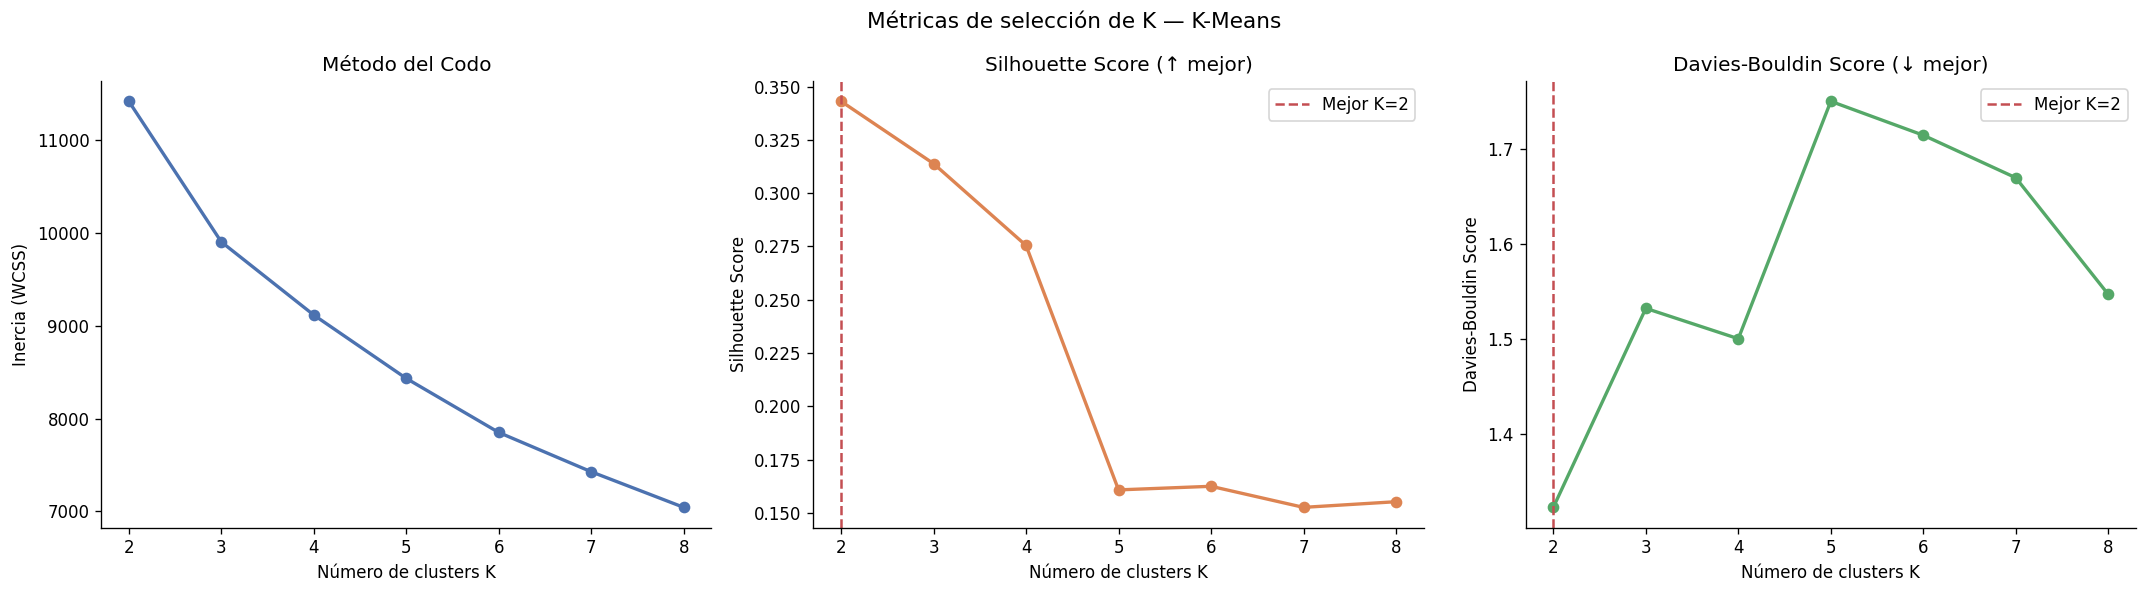


K óptimo según Silhouette: K=2
K óptimo según Davies-Bouldin: K=2


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Método del codo
axes[0].plot(k_range, inercias, "o-", color="#4C72B0", linewidth=2)
axes[0].set_xlabel("Número de clusters K")
axes[0].set_ylabel("Inercia (WCSS)")
axes[0].set_title("Método del Codo")
axes[0].set_xticks(list(k_range))

# Silhouette score (mayor = mejor)
axes[1].plot(k_range, silhouettes, "o-", color="#DD8452", linewidth=2)
axes[1].set_xlabel("Número de clusters K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score (↑ mejor)")
axes[1].set_xticks(list(k_range))
best_k_sil = list(k_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k_sil, ls="--", color="#C44E52", label=f"Mejor K={best_k_sil}")
axes[1].legend()

# Davies-Bouldin (menor = mejor)
axes[2].plot(k_range, davies_bouldins, "o-", color="#55A868", linewidth=2)
axes[2].set_xlabel("Número de clusters K")
axes[2].set_ylabel("Davies-Bouldin Score")
axes[2].set_title("Davies-Bouldin Score (↓ mejor)")
axes[2].set_xticks(list(k_range))
best_k_db = list(k_range)[np.argmin(davies_bouldins)]
axes[2].axvline(best_k_db, ls="--", color="#C44E52", label=f"Mejor K={best_k_db}")
axes[2].legend()

plt.suptitle("Métricas de selección de K — K-Means", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nK óptimo según Silhouette: K={best_k_sil}")
print(f"K óptimo según Davies-Bouldin: K={best_k_db}")

Observación: K=2 suele ser el ganador en datos de cáncer de mama Wisconsin, reflejo de la estructura binaria benigno/maligno subyacente.

### 3.2 Análisis de Métricas y Comparación de Modelos

### 3.3 Identificación del modelo con la mejor métrica:

### 3.5 Entrenamiento del mejor modelo con mas y menos features



### 3.6 Grafica de los residuos del mejor modelo



---


## 4. Conclusiones

